# **Reinforcement Learning for Fast Frequency Response using Swing Equation Dynamics**

In [ ]:
!pip install gymnasium

In [ ]:
import os

os.makedirs("src", exist_ok=True)
os.makedirs("models", exist_ok=True)

In [ ]:
%%writefile src/frequency_env.py
"""
frequency_env.py

Gymnasium environment for fast frequency response using a simplified
single-area swing-equation frequency model.

State:
    [frequency_deviation_hz, rocof_hz_per_s, energy_pu]

Action:
    battery/inverter power injection in pu, continuous in [-p_ctrl_max, p_ctrl_max]
"""

from __future__ import annotations

import numpy as np
import gymnasium as gym
from gymnasium import spaces


class FrequencyResponseEnv(gym.Env):
    metadata = {"render_modes": []}

    def __init__(
        self,
        dt: float = 0.05,
        episode_time: float = 7.50,
        H: float = 5.0,
        D: float = 1.0,
        p_ctrl_max: float = 0.3,
        energy_init: float = 1.0,
        energy_min: float = 0.0,
        energy_max: float = 1.0,
        disturbance_range: tuple[float, float] = (0.05, 0.25),
        disturbance_time_range: tuple[float, float] = (0.5, 1.5),
        freq_limit: float = 0.5,
        seed: int | None = None,
    ):
        super().__init__()

        self.dt = dt
        self.episode_time = episode_time
        self.max_steps = int(episode_time / dt)

        self.H = H
        self.D = D
        self.p_ctrl_max = p_ctrl_max

        self.energy_init = energy_init
        self.energy_min = energy_min
        self.energy_max = energy_max

        self.disturbance_range = disturbance_range
        self.disturbance_time_range = disturbance_time_range
        self.freq_limit = freq_limit

        self.observation_space = spaces.Box(
            low=np.array([-5.0, -10.0, self.energy_min], dtype=np.float32),
            high=np.array([5.0, 10.0, self.energy_max], dtype=np.float32),
            dtype=np.float32,
        )

        self.action_space = spaces.Box(
            low=np.array([-self.p_ctrl_max], dtype=np.float32),
            high=np.array([self.p_ctrl_max], dtype=np.float32),
            dtype=np.float32,
        )

        self.np_random = np.random.default_rng(seed)

        self.step_count = 0
        self.t = 0.0
        self.freq_dev = 0.0
        self.rocof = 0.0
        self.energy = self.energy_init
        self.disturbance = 0.0
        self.disturbance_time = 1.0

    def reset(self, seed: int | None = None, options: dict | None = None):
        super().reset(seed=seed)

        if seed is not None:
            self.np_random = np.random.default_rng(seed)

        self.step_count = 0
        self.t = 0.0

        self.freq_dev = 0.0
        self.rocof = 0.0
        self.energy = self.energy_init

        self.disturbance = self.np_random.uniform(*self.disturbance_range)
        self.disturbance_time = self.np_random.uniform(*self.disturbance_time_range)

        obs = self._get_obs()
        info = {
            "disturbance": self.disturbance,
            "disturbance_time": self.disturbance_time,
        }

        return obs, info

    def step(self, action):
        action = np.asarray(action, dtype=np.float32)
        p_ctrl = float(np.clip(action[0], -self.p_ctrl_max, self.p_ctrl_max))

        # No disturbance before disturbance_time.
        p_dist = self.disturbance if self.t >= self.disturbance_time else 0.0

        # Prevent discharging when energy is depleted.
        if self.energy <= self.energy_min and p_ctrl > 0:
            p_ctrl = 0.0

        # Simplified swing equation:
        # d(df)/dt = (P_ctrl - P_dist - D*df) / (2H)
        self.rocof = (p_ctrl - p_dist - self.D * self.freq_dev) / (2.0 * self.H)

        self.freq_dev += self.dt * self.rocof

        # Simple energy update. Positive p_ctrl means discharge/injection.
        self.energy -= self.dt * max(p_ctrl, 0.0)
        self.energy = float(np.clip(self.energy, self.energy_min, self.energy_max))

        self.t += self.dt
        self.step_count += 1

        reward = self._reward(p_ctrl)

        terminated = abs(self.freq_dev) > 2.0
        truncated = self.step_count >= self.max_steps

        obs = self._get_obs()

        info = {
            "time": self.t,
            "p_ctrl": p_ctrl,
            "p_dist": p_dist,
            "freq_dev": self.freq_dev,
            "rocof": self.rocof,
            "energy": self.energy,
        }

        return obs, reward, terminated, truncated, info

    def _get_obs(self):
        return np.array(
            [self.freq_dev, self.rocof, self.energy],
            dtype=np.float32,
        )

    def _reward(self, p_ctrl: float):
        freq_penalty = 20.0 * self.freq_dev**2
        rocof_penalty = 2.0 * self.rocof**2
        control_penalty = 0.1 * p_ctrl**2
        limit_penalty = 50.0 * max(0.0, abs(self.freq_dev) - self.freq_limit) ** 2

        return -(freq_penalty + rocof_penalty + control_penalty + limit_penalty)


def droop_controller(obs, k_droop: float = 8.0, p_ctrl_max: float = 0.3):
    freq_dev, _, energy = obs

    # If frequency is below nominal, freq_dev is negative, so inject positive power.
    p_ctrl = -k_droop * freq_dev

    if energy <= 0.0 and p_ctrl > 0:
        p_ctrl = 0.0

    return np.array([np.clip(p_ctrl, -p_ctrl_max, p_ctrl_max)], dtype=np.float32)


if __name__ == "__main__":
    env = FrequencyResponseEnv(seed=469)

    obs, info = env.reset()
    print("Initial observation:", obs)
    print("Disturbance info:", info)

    total_reward = 0.0

    for _ in range(env.max_steps):
        action = droop_controller(obs, p_ctrl_max=env.p_ctrl_max)
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += reward

        if terminated or truncated:
            break

    print("Final observation:", obs)
    print("Total reward:", total_reward)
    print("Final info:", info)

Overwriting src/frequency_env.py


In [ ]:
!python src/frequency_env.py

Initial observation: [0. 0. 1.]
Disturbance info: {'disturbance': 0.15101516949960725, 'disturbance_time': 1.4730576291397752}
Final observation: [-1.671260e-02 -6.301142e-05  3.431422e-01]
Total reward: -0.6581740303633566
Final info: {'time': 7.499999999999981, 'p_ctrl': 0.13367560505867004, 'p_dist': 0.15101516949960725, 'freq_dev': -0.016712600759608263, 'rocof': -6.301142525919033e-05, 'energy': 0.34314221376553156}


In [ ]:
%%writefile src/ddpg_agent.py
"""
ddpg_agent.py

Basic DDPG components for continuous-control reinforcement learning.

DDPG = Deep Deterministic Policy Gradient.

It is useful here because:
    - the state is continuous: [frequency deviation, RoCoF, energy]
    - the action is continuous: inverter/battery power injection
"""

from __future__ import annotations

from dataclasses import dataclass
import random
from collections import deque

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim


class Actor(nn.Module):
    """
    Actor network.

    Input:
        state vector

    Output:
        continuous action in [-action_limit, action_limit]
    """

    def __init__(self, state_dim: int, action_dim: int, action_limit: float):
        super().__init__()

        self.action_limit = action_limit

        self.net = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim),
            nn.Tanh(),
        )

    def forward(self, state):
        return self.action_limit * self.net(state)


class Critic(nn.Module):
    """
    Critic network.

    Input:
        state and action

    Output:
        Q-value, which estimates how good that action is in that state
    """

    def __init__(self, state_dim: int, action_dim: int):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(state_dim + action_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
        )

    def forward(self, state, action):
        x = torch.cat([state, action], dim=-1)
        return self.net(x)


class ReplayBuffer:
    """
    Stores past experience tuples:

        (state, action, reward, next_state, done)

    DDPG samples random batches from this buffer for training.
    """

    def __init__(self, capacity: int = 100_000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size: int):
        batch = random.sample(self.buffer, batch_size)

        states, actions, rewards, next_states, dones = zip(*batch)

        return (
            np.array(states, dtype=np.float32),
            np.array(actions, dtype=np.float32),
            np.array(rewards, dtype=np.float32).reshape(-1, 1),
            np.array(next_states, dtype=np.float32),
            np.array(dones, dtype=np.float32).reshape(-1, 1),
        )

    def __len__(self):
        return len(self.buffer)


@dataclass
class DDPGConfig:
    gamma: float = 0.99
    tau: float = 0.005
    actor_lr: float = 1e-4
    critic_lr: float = 1e-3
    batch_size: int = 128
    replay_capacity: int = 100_000
    exploration_noise: float = 0.05


class DDPGAgent:
    """
    DDPG agent.

    The actor chooses actions.
    The critic evaluates actions.
    Target networks stabilize learning.
    """

    def __init__(
        self,
        state_dim: int,
        action_dim: int,
        action_limit: float,
        device: torch.device | str = "cpu",
        config: DDPGConfig | None = None,
    ):
        self.device = torch.device(device)
        self.config = config or DDPGConfig()

        self.state_dim = state_dim
        self.action_dim = action_dim
        self.action_limit = action_limit

        self.actor = Actor(state_dim, action_dim, action_limit).to(self.device)
        self.actor_target = Actor(state_dim, action_dim, action_limit).to(self.device)

        self.critic = Critic(state_dim, action_dim).to(self.device)
        self.critic_target = Critic(state_dim, action_dim).to(self.device)

        self.actor_target.load_state_dict(self.actor.state_dict())
        self.critic_target.load_state_dict(self.critic.state_dict())

        self.actor_optimizer = optim.Adam(self.actor.parameters(), lr=self.config.actor_lr)
        self.critic_optimizer = optim.Adam(self.critic.parameters(), lr=self.config.critic_lr)

        self.replay_buffer = ReplayBuffer(capacity=self.config.replay_capacity)

    def select_action(self, state, add_noise: bool = True):
        """
        Select action from the actor network.

        During training, we add noise so the agent explores.
        During evaluation, we do not add noise.
        """
        state_tensor = torch.as_tensor(state, dtype=torch.float32, device=self.device).unsqueeze(0)

        self.actor.eval()
        with torch.no_grad():
            action = self.actor(state_tensor).cpu().numpy()[0]
        self.actor.train()

        if add_noise:
            noise = np.random.normal(
                loc=0.0,
                scale=self.config.exploration_noise,
                size=self.action_dim,
            )
            action = action + noise

        action = np.clip(action, -self.action_limit, self.action_limit)
        return action.astype(np.float32)

    def update(self):
        """
        Perform one DDPG update step.

        Returns:
            dictionary with actor and critic losses,
            or None if the replay buffer is not ready.
        """
        if len(self.replay_buffer) < self.config.batch_size:
            return None

        states, actions, rewards, next_states, dones = self.replay_buffer.sample(
            self.config.batch_size
        )

        states = torch.as_tensor(states, dtype=torch.float32, device=self.device)
        actions = torch.as_tensor(actions, dtype=torch.float32, device=self.device)
        rewards = torch.as_tensor(rewards, dtype=torch.float32, device=self.device)
        next_states = torch.as_tensor(next_states, dtype=torch.float32, device=self.device)
        dones = torch.as_tensor(dones, dtype=torch.float32, device=self.device)

        # -------------------------
        # Critic update
        # -------------------------
        with torch.no_grad():
            next_actions = self.actor_target(next_states)
            target_q = self.critic_target(next_states, next_actions)
            y = rewards + self.config.gamma * (1.0 - dones) * target_q

        current_q = self.critic(states, actions)
        critic_loss = nn.functional.mse_loss(current_q, y)

        self.critic_optimizer.zero_grad()
        critic_loss.backward()
        self.critic_optimizer.step()

        # -------------------------
        # Actor update
        # -------------------------
        predicted_actions = self.actor(states)
        actor_loss = -self.critic(states, predicted_actions).mean()

        self.actor_optimizer.zero_grad()
        actor_loss.backward()
        self.actor_optimizer.step()

        # -------------------------
        # Target network soft update
        # -------------------------
        self._soft_update(self.actor_target, self.actor)
        self._soft_update(self.critic_target, self.critic)

        return {
            "actor_loss": float(actor_loss.item()),
            "critic_loss": float(critic_loss.item()),
        }

    def _soft_update(self, target_net, source_net):
        tau = self.config.tau

        for target_param, source_param in zip(target_net.parameters(), source_net.parameters()):
            target_param.data.copy_(
                tau * source_param.data + (1.0 - tau) * target_param.data
            )

    def save(self, actor_path: str, critic_path: str):
        torch.save(self.actor.state_dict(), actor_path)
        torch.save(self.critic.state_dict(), critic_path)

    def load(self, actor_path: str, critic_path: str | None = None):
        self.actor.load_state_dict(torch.load(actor_path, map_location=self.device))
        self.actor_target.load_state_dict(self.actor.state_dict())

        if critic_path is not None:
            self.critic.load_state_dict(torch.load(critic_path, map_location=self.device))
            self.critic_target.load_state_dict(self.critic.state_dict())

Overwriting src/ddpg_agent.py


In [ ]:
from src.ddpg_agent import DDPGAgent, DDPGConfig

import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

agent = DDPGAgent(
    state_dim=3,
    action_dim=1,
    action_limit=0.3,
    device=device,
)

print(agent)
print("DDPG agent created successfully on:", device)

DDPG agent created successfully on: cuda


In [ ]:
%%writefile train_rl_frequency_agent.py
"""
train_rl_frequency_agent.py

Training script for the RL fast frequency response example.

This script:
    1. Creates the frequency-response environment
    2. Trains a DDPG agent
    3. Saves a partially trained model for workshop fine-tuning
    4. Saves a better pretrained model for instructor demonstration
"""

import os
import random
import numpy as np
import torch
import matplotlib.pyplot as plt

from src.frequency_env import FrequencyResponseEnv
from src.ddpg_agent import DDPGAgent, DDPGConfig


# -----------------------------
# Reproducibility
# -----------------------------
SEED = 469

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# -----------------------------
# Paths
# -----------------------------
MODEL_DIR = "models"
os.makedirs(MODEL_DIR, exist_ok=True)

STARTING_ACTOR_PATH = os.path.join(MODEL_DIR, "rl_actor_starting_point.pt")
STARTING_CRITIC_PATH = os.path.join(MODEL_DIR, "rl_critic_starting_point.pt")

PRETRAINED_ACTOR_PATH = os.path.join(MODEL_DIR, "rl_actor_pretrained.pt")
PRETRAINED_CRITIC_PATH = os.path.join(MODEL_DIR, "rl_critic_pretrained.pt")


# -----------------------------
# Device
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# -----------------------------
# Environment
# -----------------------------
env = FrequencyResponseEnv(
    dt=0.05,
    episode_time=7.50,
    H=5.0,
    D=1.0,
    p_ctrl_max=0.3,
    disturbance_range=(0.05, 0.25),
    disturbance_time_range=(0.5, 1.5),
    seed=SEED,
)

state_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]
action_limit = float(env.action_space.high[0])


# -----------------------------
# Agent
# -----------------------------
config = DDPGConfig(
    gamma=0.99,
    tau=0.005,
    actor_lr=1e-4,
    critic_lr=1e-3,
    batch_size=128,
    replay_capacity=100_000,
    exploration_noise=0.08,
)

agent = DDPGAgent(
    state_dim=state_dim,
    action_dim=action_dim,
    action_limit=action_limit,
    device=device,
    config=config,
)


# -----------------------------
# Training settings
# -----------------------------
N_EPISODES = 500
STARTING_POINT_EPISODE = 100
UPDATES_PER_STEP = 1

episode_rewards = []


# -----------------------------
# Training loop
# -----------------------------
for episode in range(1, N_EPISODES + 1):
    state, info = env.reset(seed=SEED + episode)

    total_reward = 0.0
    actor_losses = []
    critic_losses = []

    for step in range(env.max_steps):
        action = agent.select_action(state, add_noise=True)

        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        agent.replay_buffer.push(
            state,
            action,
            reward,
            next_state,
            float(done),
        )

        for _ in range(UPDATES_PER_STEP):
            losses = agent.update()
            if losses is not None:
                actor_losses.append(losses["actor_loss"])
                critic_losses.append(losses["critic_loss"])

        state = next_state
        total_reward += reward

        if done:
            break

    episode_rewards.append(total_reward)

    if episode == STARTING_POINT_EPISODE:
        agent.save(STARTING_ACTOR_PATH, STARTING_CRITIC_PATH)
        print(f"Saved starting-point model at episode {episode}")

    if episode % 25 == 0:
        avg_reward = np.mean(episode_rewards[-25:])
        print(
            f"Episode {episode:4d} | "
            f"Avg reward (last 25): {avg_reward:9.3f} | "
            f"Replay size: {len(agent.replay_buffer)}"
        )


# -----------------------------
# Save final pretrained model
# -----------------------------
agent.save(PRETRAINED_ACTOR_PATH, PRETRAINED_CRITIC_PATH)

print("Training complete.")
print("Saved:")
print(" ", STARTING_ACTOR_PATH)
print(" ", STARTING_CRITIC_PATH)
print(" ", PRETRAINED_ACTOR_PATH)
print(" ", PRETRAINED_CRITIC_PATH)


# -----------------------------
# Plot training curve
# -----------------------------
plt.figure()
plt.plot(episode_rewards)
plt.xlabel("Episode")
plt.ylabel("Total reward")
plt.title("DDPG Training Curve")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, "rl_training_curve.png"), dpi=200)
plt.show()

Overwriting train_rl_frequency_agent.py


In [ ]:
!python train_rl_frequency_agent.py

Using device: cuda
Episode   25 | Avg reward (last 25):    -4.005 | Replay size: 3750
Episode   50 | Avg reward (last 25):    -4.212 | Replay size: 7500
Episode   75 | Avg reward (last 25):    -1.891 | Replay size: 11250
Saved starting-point model at episode 100
Episode  100 | Avg reward (last 25):    -0.736 | Replay size: 15000
Episode  125 | Avg reward (last 25):    -0.516 | Replay size: 18750
Episode  150 | Avg reward (last 25):    -0.588 | Replay size: 22500
Episode  175 | Avg reward (last 25):    -0.675 | Replay size: 26250
Episode  200 | Avg reward (last 25):    -0.584 | Replay size: 30000
Episode  225 | Avg reward (last 25):    -0.516 | Replay size: 33750
Episode  250 | Avg reward (last 25):    -0.527 | Replay size: 37500
Episode  275 | Avg reward (last 25):    -0.542 | Replay size: 41250
Episode  300 | Avg reward (last 25):    -0.946 | Replay size: 45000
Episode  325 | Avg reward (last 25):    -0.572 | Replay size: 48750
Episode  350 | Avg reward (last 25):    -0.532 | Replay s

In [ ]:
!ls -lh models

total 384K
-rw-r--r-- 1 root root 71K Jun 15 08:02 rl_actor_pretrained.pt
-rw-r--r-- 1 root root 71K Jun 15 07:56 rl_actor_starting_point.pt
-rw-r--r-- 1 root root 71K Jun 15 08:02 rl_critic_pretrained.pt
-rw-r--r-- 1 root root 71K Jun 15 07:56 rl_critic_starting_point.pt
-rw-r--r-- 1 root root 95K Jun 15 08:02 rl_training_curve.png


# Sanity check

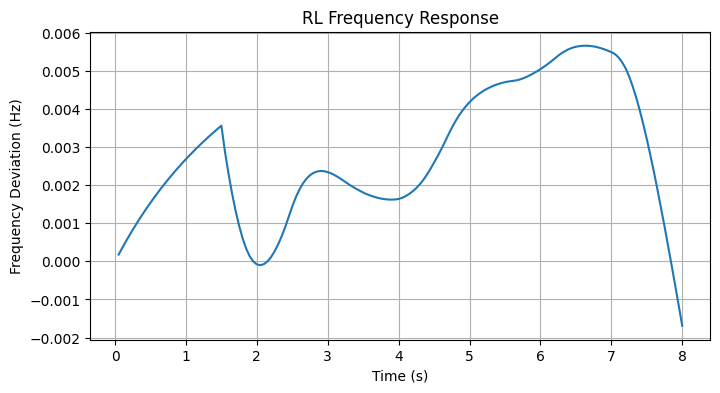

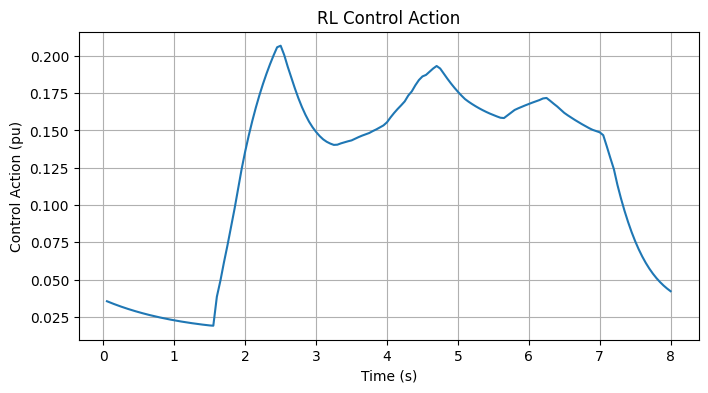

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from src.frequency_env import FrequencyResponseEnv
from src.ddpg_agent import DDPGAgent


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

env = FrequencyResponseEnv(seed=469)

agent = DDPGAgent(
    state_dim=3,
    action_dim=1,
    action_limit=0.3,
    device=device,
)

agent.load(
    "models/rl_actor_pretrained.pt",
    "models/rl_critic_pretrained.pt",
)

state, info = env.reset()

times = []
freqs = []
actions = []

done = False

while not done:

    action = agent.select_action(state, add_noise=False)

    next_state, reward, terminated, truncated, info = env.step(action)

    times.append(info["time"])
    freqs.append(info["freq_dev"])
    actions.append(info["p_ctrl"])

    state = next_state
    done = terminated or truncated

plt.figure(figsize=(8,4))
plt.plot(times, freqs)
plt.xlabel("Time (s)")
plt.ylabel("Frequency Deviation (Hz)")
plt.title("RL Frequency Response")
plt.grid(True)
plt.show()

plt.figure(figsize=(8,4))
plt.plot(times, actions)
plt.xlabel("Time (s)")
plt.ylabel("Control Action (pu)")
plt.title("RL Control Action")
plt.grid(True)
plt.show()

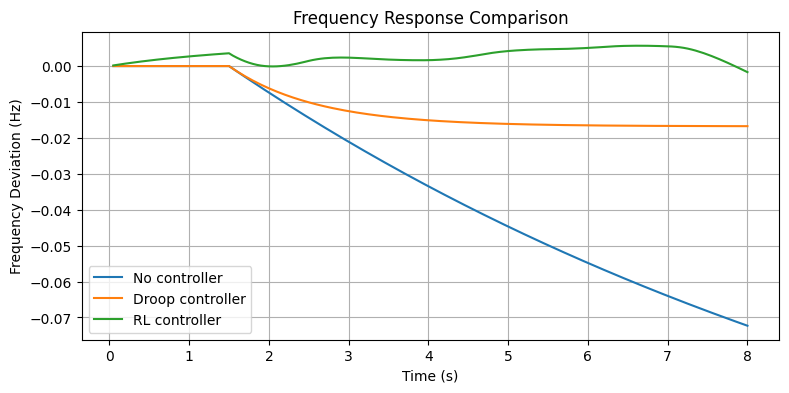

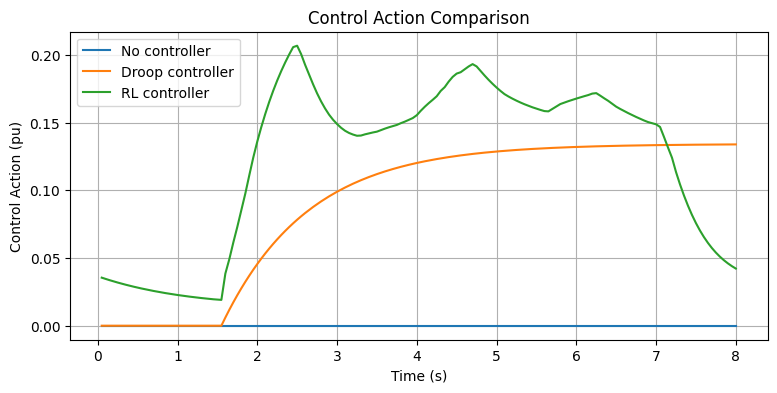

{'Controller': 'No controller', 'Min freq dev (Hz)': np.float64(-0.07230677179722596), 'Final freq dev (Hz)': np.float64(-0.07230677179722596), 'Max |action| (pu)': np.float64(0.0), 'Total reward': np.float64(-5.38142638351149)}
{'Controller': 'Droop controller', 'Min freq dev (Hz)': np.float64(-0.01673727259963922), 'Final freq dev (Hz)': np.float64(-0.01673727259963922), 'Max |action| (pu)': np.float64(0.1338822841644287), 'Total reward': np.float64(-0.7320349583993032)}
{'Controller': 'RL controller', 'Min freq dev (Hz)': np.float64(-0.0016902601800296226), 'Final freq dev (Hz)': np.float64(-0.0016902601800296226), 'Max |action| (pu)': np.float64(0.20675286650657654), 'Total reward': np.float64(-0.3415546437309458)}


In [ ]:
from src.frequency_env import FrequencyResponseEnv, droop_controller
import torch
import numpy as np
import matplotlib.pyplot as plt

from src.frequency_env import FrequencyResponseEnv, droop_controller
from src.ddpg_agent import DDPGAgent


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# -----------------------------
# Load trained RL agent
# -----------------------------
rl_agent = DDPGAgent(
    state_dim=3,
    action_dim=1,
    action_limit=0.3,
    device=device,
)

rl_agent.load(
    "models/rl_actor_pretrained.pt",
    "models/rl_critic_pretrained.pt",
)


# -----------------------------
# Helper function
# -----------------------------
def simulate_controller(controller_type, seed=469):
    env = FrequencyResponseEnv(seed=seed)
    state, info = env.reset(seed=seed)

    times = []
    freqs = []
    actions = []
    rewards = []

    done = False

    while not done:
        if controller_type == "none":
            action = np.array([0.0], dtype=np.float32)

        elif controller_type == "droop":
            action = droop_controller(
                state,
                k_droop=8.0,
                p_ctrl_max=env.p_ctrl_max,
            )

        elif controller_type == "rl":
            action = rl_agent.select_action(state, add_noise=False)

        else:
            raise ValueError("Unknown controller type.")

        next_state, reward, terminated, truncated, info = env.step(action)

        times.append(info["time"])
        freqs.append(info["freq_dev"])
        actions.append(info["p_ctrl"])
        rewards.append(reward)

        state = next_state
        done = terminated or truncated

    return {
        "time": np.array(times),
        "freq": np.array(freqs),
        "action": np.array(actions),
        "reward": np.array(rewards),
    }


# -----------------------------
# Run all three cases
# -----------------------------
results_none = simulate_controller("none", seed=469)
results_droop = simulate_controller("droop", seed=469)
results_rl = simulate_controller("rl", seed=469)


# -----------------------------
# Plot frequency response
# -----------------------------
plt.figure(figsize=(9, 4))
plt.plot(results_none["time"], results_none["freq"], label="No controller")
plt.plot(results_droop["time"], results_droop["freq"], label="Droop controller")
plt.plot(results_rl["time"], results_rl["freq"], label="RL controller")
plt.xlabel("Time (s)")
plt.ylabel("Frequency Deviation (Hz)")
plt.title("Frequency Response Comparison")
plt.grid(True)
plt.legend()
plt.show()


# -----------------------------
# Plot control actions
# -----------------------------
plt.figure(figsize=(9, 4))
plt.plot(results_none["time"], results_none["action"], label="No controller")
plt.plot(results_droop["time"], results_droop["action"], label="Droop controller")
plt.plot(results_rl["time"], results_rl["action"], label="RL controller")
plt.xlabel("Time (s)")
plt.ylabel("Control Action (pu)")
plt.title("Control Action Comparison")
plt.grid(True)
plt.legend()
plt.show()


# -----------------------------
# Compute simple metrics
# -----------------------------
def summarize(name, results):
    freq = results["freq"]
    action = results["action"]
    reward = results["reward"]

    return {
        "Controller": name,
        "Min freq dev (Hz)": np.min(freq),
        "Final freq dev (Hz)": freq[-1],
        "Max |action| (pu)": np.max(np.abs(action)),
        "Total reward": np.sum(reward),
    }


summary = [
    summarize("No controller", results_none),
    summarize("Droop controller", results_droop),
    summarize("RL controller", results_rl),
]

for row in summary:
    print(row)

In [ ]:
import os
import nbformat as nbf

os.makedirs("notebooks", exist_ok=True)

nb = nbf.v4.new_notebook()

cells = []

cells.append(nbf.v4.new_markdown_cell("""
# Reinforcement Learning for Fast Frequency Response

This notebook demonstrates how reinforcement learning can be used for fast frequency response in a simplified power-system model.

We compare three cases:

1. No controller
2. Droop controller
3. Reinforcement-learning controller

The RL controller is trained using a simple DDPG-style actor-critic model.
"""))

cells.append(nbf.v4.new_code_cell("""
# Install required package if running in a fresh Colab runtime
!pip install -q gymnasium
"""))

cells.append(nbf.v4.new_code_cell("""
import os
import random
import numpy as np
import torch
import matplotlib.pyplot as plt

from src.frequency_env import FrequencyResponseEnv, droop_controller
from src.ddpg_agent import DDPGAgent, DDPGConfig

SEED = 469

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
"""))

cells.append(nbf.v4.new_markdown_cell("""
## 1. Simplified frequency-response model

We use a single-area swing-equation model:

\\[
\\frac{d\\Delta f}{dt}
=
\\frac{P_{ctrl} - \\Delta P_L - D\\Delta f}{2H}
\\]

where:

- \\(\\Delta f\\) is frequency deviation from nominal frequency,
- \\(P_{ctrl}\\) is inverter/battery power injection,
- \\(\\Delta P_L\\) is a load disturbance,
- \\(H\\) represents system inertia,
- \\(D\\) represents damping.

The RL agent observes:

\\[
s_t = [\\Delta f_t, RoCoF_t, E_t]
\\]

and outputs:

\\[
a_t = P_{ctrl}
\\]
"""))

cells.append(nbf.v4.new_code_cell("""
def make_env(seed=469):
    return FrequencyResponseEnv(
        dt=0.05,
        episode_time=8.0,
        H=5.0,
        D=1.0,
        p_ctrl_max=0.3,
        energy_init=1.0,
        energy_max=1.0,
        disturbance_range=(0.05, 0.25),
        disturbance_time_range=(0.5, 1.5),
        seed=seed,
    )
"""))

cells.append(nbf.v4.new_markdown_cell("""
## 2. Load pretrained RL controller

The instructor demonstration uses a pretrained actor network.
"""))

cells.append(nbf.v4.new_code_cell("""
rl_agent = DDPGAgent(
    state_dim=3,
    action_dim=1,
    action_limit=0.3,
    device=device,
)

rl_agent.load(
    "models/rl_actor_pretrained.pt",
    "models/rl_critic_pretrained.pt",
)

print("Pretrained RL model loaded.")
"""))

cells.append(nbf.v4.new_code_cell("""
def simulate_controller(controller_type, seed=469, agent=None):
    env = make_env(seed)
    state, info = env.reset(seed=seed)

    times = []
    freqs = []
    rocofs = []
    actions = []
    energies = []
    rewards = []

    done = False

    while not done:
        if controller_type == "none":
            action = np.array([0.0], dtype=np.float32)

        elif controller_type == "droop":
            action = droop_controller(
                state,
                k_droop=8.0,
                p_ctrl_max=env.p_ctrl_max,
            )

        elif controller_type == "rl":
            action = agent.select_action(state, add_noise=False)

        else:
            raise ValueError("Unknown controller type.")

        next_state, reward, terminated, truncated, info = env.step(action)

        times.append(info["time"])
        freqs.append(info["freq_dev"])
        rocofs.append(info["rocof"])
        actions.append(info["p_ctrl"])
        energies.append(info["energy"])
        rewards.append(reward)

        state = next_state
        done = terminated or truncated

    return {
        "time": np.array(times),
        "freq": np.array(freqs),
        "rocof": np.array(rocofs),
        "action": np.array(actions),
        "energy": np.array(energies),
        "reward": np.array(rewards),
    }
"""))

cells.append(nbf.v4.new_markdown_cell("""
## 3. Compare no control, droop control, and RL control
"""))

cells.append(nbf.v4.new_code_cell("""
results_none = simulate_controller("none", seed=SEED, agent=None)
results_droop = simulate_controller("droop", seed=SEED, agent=None)
results_rl = simulate_controller("rl", seed=SEED, agent=rl_agent)

plt.figure(figsize=(9, 4))
plt.plot(results_none["time"], results_none["freq"], label="No controller")
plt.plot(results_droop["time"], results_droop["freq"], label="Droop controller")
plt.plot(results_rl["time"], results_rl["freq"], label="RL controller")
plt.xlabel("Time (s)")
plt.ylabel("Frequency deviation (Hz)")
plt.title("Frequency Response Comparison")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(results_none["time"], results_none["action"], label="No controller")
plt.plot(results_droop["time"], results_droop["action"], label="Droop controller")
plt.plot(results_rl["time"], results_rl["action"], label="RL controller")
plt.xlabel("Time (s)")
plt.ylabel("Control action (pu)")
plt.title("Control Action Comparison")
plt.grid(True)
plt.legend()
plt.show()
"""))

cells.append(nbf.v4.new_code_cell("""
def summarize(name, results):
    freq = results["freq"]
    action = results["action"]
    reward = results["reward"]

    return {
        "Controller": name,
        "Minimum frequency deviation (Hz)": np.min(freq),
        "Final frequency deviation (Hz)": freq[-1],
        "Maximum absolute action (pu)": np.max(np.abs(action)),
        "Total reward": np.sum(reward),
    }

summary = [
    summarize("No controller", results_none),
    summarize("Droop controller", results_droop),
    summarize("RL controller", results_rl),
]

for row in summary:
    print(row)
"""))

cells.append(nbf.v4.new_markdown_cell("""
## 4. Participant exercise: fine-tune a starting-point RL model

Now we load a partially trained model and fine-tune it for a small number of episodes.

The goal is not to train from scratch, but to show the RL training loop.
"""))

cells.append(nbf.v4.new_code_cell("""
student_agent = DDPGAgent(
    state_dim=3,
    action_dim=1,
    action_limit=0.3,
    device=device,
    config=DDPGConfig(
        gamma=0.99,
        tau=0.005,
        actor_lr=1e-4,
        critic_lr=1e-3,
        batch_size=128,
        replay_capacity=100_000,
        exploration_noise=0.05,
    )
)

student_agent.load(
    "models/rl_actor_starting_point.pt",
    "models/rl_critic_starting_point.pt",
)

print("Starting-point model loaded.")
"""))

cells.append(nbf.v4.new_code_cell("""
def fine_tune(agent, n_episodes=20):
    episode_rewards = []

    for episode in range(1, n_episodes + 1):
        env = make_env(seed=SEED + episode)
        state, info = env.reset(seed=SEED + episode)

        total_reward = 0.0
        done = False

        while not done:
            action = agent.select_action(state, add_noise=True)
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            agent.replay_buffer.push(
                state,
                action,
                reward,
                next_state,
                float(done),
            )

            agent.update()

            state = next_state
            total_reward += reward

        episode_rewards.append(total_reward)

    return episode_rewards


fine_tune_rewards = fine_tune(student_agent, n_episodes=20)

plt.figure(figsize=(8, 4))
plt.plot(fine_tune_rewards)
plt.xlabel("Fine-tuning episode")
plt.ylabel("Total reward")
plt.title("Short Fine-Tuning Run")
plt.grid(True)
plt.show()
"""))

cells.append(nbf.v4.new_code_cell("""
results_student = simulate_controller("rl", seed=SEED, agent=student_agent)

plt.figure(figsize=(9, 4))
plt.plot(results_rl["time"], results_rl["freq"], label="Instructor pretrained RL")
plt.plot(results_student["time"], results_student["freq"], label="Fine-tuned starting-point RL")
plt.xlabel("Time (s)")
plt.ylabel("Frequency deviation (Hz)")
plt.title("Instructor Model vs Fine-Tuned Student Model")
plt.grid(True)
plt.legend()
plt.show()
"""))

cells.append(nbf.v4.new_markdown_cell("""
## 5. Key takeaways

- Fast frequency response is needed when a sudden power imbalance causes frequency to deviate.
- A droop controller provides a simple physics-based baseline.
- A reinforcement-learning controller can learn a control policy from repeated interaction with a simulated environment.
- RL performance depends strongly on reward design, training data, physical constraints, and safety limits.

## Next steps

More advanced versions could include:

- Soft Actor-Critic instead of DDPG,
- multi-area frequency dynamics,
- battery state-of-charge limits,
- inverter ramp-rate constraints,
- grid-forming inverter models,
- multi-agent RL for distributed energy resources.
"""))

nb["cells"] = cells

output_path = "notebooks/03_rl_frequency_response.ipynb"

with open(output_path, "w", encoding="utf-8") as f:
    nbf.write(nb, f)

print(f"Notebook created: {output_path}")

SyntaxError: incomplete input (268772217.py, line 163)

In [ ]:
!ls -lh notebooks

total 16K
-rw-r--r-- 1 root root 13K Jun 15 08:10 03_rl_frequency_response.ipynb


In [ ]:
!zip -r rl_frequency_workshop.zip src models notebooks train_rl_frequency_agent.py

  adding: src/ (stored 0%)
  adding: src/__pycache__/ (stored 0%)
  adding: src/__pycache__/ddpg_agent.cpython-312.pyc (deflated 57%)
  adding: src/__pycache__/frequency_env.cpython-312.pyc (deflated 51%)
  adding: src/frequency_env.py (deflated 71%)
  adding: src/ddpg_agent.py (deflated 74%)
  adding: models/ (stored 0%)
  adding: models/rl_training_curve.png (deflated 7%)
  adding: models/rl_actor_starting_point.pt (deflated 10%)
  adding: models/rl_critic_starting_point.pt (deflated 10%)
  adding: models/rl_actor_pretrained.pt (deflated 9%)
  adding: models/rl_critic_pretrained.pt (deflated 9%)
  adding: notebooks/ (stored 0%)
  adding: notebooks/03_rl_frequency_response.ipynb (deflated 76%)
  adding: train_rl_frequency_agent.py (deflated 65%)
